## K-means on Iris dataset
We know that iris dataset has 3 clusters. I use kmeans to find these 3 clusters and then compare it with actual labels. The match is 80% +.  

In [31]:
import pandas as pd

# %matplotlib inline
# import warnings
# warnings.filterwarnings('ignore')

# imports
import matplotlib.pyplot as plt, numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 6)

In [32]:
# ## 1. Problem formulation
# Find clusters

In [33]:
# 2. Data collection
df = pd.read_csv("data_iris.csv")

# or use below to get file
# df = pd.read_csv("https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/iris.csv")

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [34]:
# 3. Data labelling
# This is unsupervised learning, so data labelling is not required here.

In [35]:
# 4. EDA

# lets look at the columns data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [36]:
# lets look at the common statistics
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [37]:
## more EDA can be done here, like plotting scatter plot between all pairs

In [38]:
species_mapping = {
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
}

df['species'] = df['species'].map(species_mapping)
print(df.sample(10))

     sepal_length  sepal_width  petal_length  petal_width  species
120           6.9          3.2           5.7          2.3        2
65            6.7          3.1           4.4          1.4        1
44            5.1          3.8           1.9          0.4        0
3             4.6          3.1           1.5          0.2        0
79            5.7          2.6           3.5          1.0        1
138           6.0          3.0           4.8          1.8        2
86            6.7          3.1           4.7          1.5        1
1             4.9          3.0           1.4          0.2        0
59            5.2          2.7           3.9          1.4        1
90            5.5          2.6           4.4          1.2        1


In [40]:
# Feature selection (assuming all columns except 'id' are relevant)
# X = df.drop(['species'], axis=1).to_numpy()  # keep all columns except target columns
X = df.drop(['species'], axis=1).to_numpy()  # keep all columns except target columns

print(X)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [41]:
# Scale the features for better clustering performance

scaler = StandardScaler()
scaler.fit(X)
scaled_X = scaler.transform(X)

In [43]:
print(f"First 10 scaled features: \n{scaled_X[:10]}")
print("########################")

## OR you can look at unscaled/scaled feature side-by-side
print(X[0], "------>", scaled_X[0])
print(X[1], "------>", scaled_X[1])

First 10 scaled features: 
[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]
 [-0.53717756  1.95766909 -1.17067529 -1.05003079]
 [-1.50652052  0.80065426 -1.3412724  -1.18150376]
 [-1.02184904  0.80065426 -1.2844067  -1.31297673]
 [-1.74885626 -0.35636057 -1.3412724  -1.31297673]
 [-1.14301691  0.10644536 -1.2844067  -1.4444497 ]]
########################
[5.1 3.5 1.4 0.2] ------> [-0.90068117  1.03205722 -1.3412724  -1.31297673]
[4.9 3.  1.4 0.2] ------> [-1.14301691 -0.1249576  -1.3412724  -1.31297673]


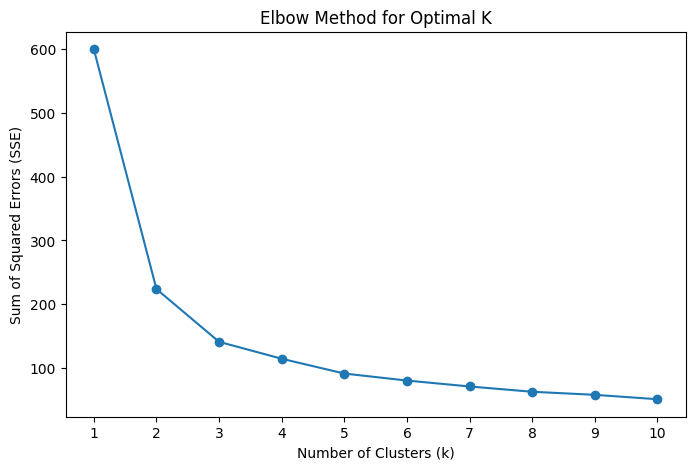

In [44]:
# Elbow method to determine the optimal K
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_X)
    sse.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.show()

In [45]:
# We see from above that K=3, is the optimal

# Apply KMeans clustering (K=3) with scaling
kmeans_with_scaling = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_with_scaling = kmeans_with_scaling.fit_predict(scaled_X)

# Add cluster labels to the DataFrame
df["Cluster_With_Scaling"] = clusters_with_scaling

# Print cluster centers (scaled)
print("Cluster Centers (With Scaling - Standardized Features):")
print(kmeans_with_scaling.cluster_centers_)

Cluster Centers (With Scaling - Standardized Features):
[[-0.05021989 -0.88029181  0.34753171  0.28206327]
 [-1.01457897  0.84230679 -1.30487835 -1.25512862]
 [ 1.13597027  0.09659843  0.996271    1.01717187]]


In [46]:
# lets print the cluster labels of the few points
print(kmeans_with_scaling.labels_[:10])

[1 1 1 1 1 1 1 1 1 1]


In [47]:
print(df)

     sepal_length  sepal_width  petal_length  petal_width  species  \
0             5.1          3.5           1.4          0.2        0   
1             4.9          3.0           1.4          0.2        0   
2             4.7          3.2           1.3          0.2        0   
3             4.6          3.1           1.5          0.2        0   
4             5.0          3.6           1.4          0.2        0   
..            ...          ...           ...          ...      ...   
145           6.7          3.0           5.2          2.3        2   
146           6.3          2.5           5.0          1.9        2   
147           6.5          3.0           5.2          2.0        2   
148           6.2          3.4           5.4          2.3        2   
149           5.9          3.0           5.1          1.8        2   

     Cluster_With_Scaling  
0                       1  
1                       1  
2                       1  
3                       1  
4                  

In [48]:
# Lets see how many clusters and their corresponding counts
import numpy as np
unique, counts = np.unique(kmeans_with_scaling.labels_, return_counts=True)

print(unique)
print(counts)

[0 1 2]
[53 50 47]


In [49]:
# Lets zip above and put them in dictionary: key=cluster-label : value=count on how many belong to each clusters
dict_data = dict(zip(unique, counts))
print(dict_data)

{0: 53, 1: 50, 2: 47}


In [50]:
# KMeans assigns cluster labels arbitrarily. That means Cluster 0 doesn’t necessarily
# correspond to Class 0 — but that’s totally fine.

# You don't fix KMeans labels directly, but you relabel the clusters to best match 
# the actual classes using a mapping based on the majority vote within each cluster.

import numpy as np
from scipy.stats import mode

# Create an empty mapping
label_mapping = {}

# For each cluster label, find the most common actual target label
for i in range(3):
    # Find rows where the cluster label is equal to i
    mask = df['Cluster_With_Scaling'] == i
    print(f"\nCluster {i} contains {mask.sum()} samples.")

    # Extract the actual class labels (target values) of these rows
    # actual_targets = df[mask]['species']
    actual_targets = df[mask]['species']
    print(f"Actual class distribution in cluster {i}:\n{actual_targets.value_counts().to_string()}")

    # Find the most common actual target (majority class) in this cluster
    most_common = mode(actual_targets, keepdims=True).mode[0]
    print(f"Most common target in cluster {i}: {most_common}")

    # Add to the mapping
    label_mapping[i] = most_common


print("Cluster-to-Class Mapping:", label_mapping)
print(f"df.head(150):\n{df.head(150)}")

# Map KMeans cluster labels to target labels
df['Cluster_Mapped'] = df['Cluster_With_Scaling'].map(label_mapping)


Cluster 0 contains 53 samples.
Actual class distribution in cluster 0:
species
1    39
2    14
Most common target in cluster 0: 1

Cluster 1 contains 50 samples.
Actual class distribution in cluster 1:
species
0    50
Most common target in cluster 1: 0

Cluster 2 contains 47 samples.
Actual class distribution in cluster 2:
species
2    36
1    11
Most common target in cluster 2: 2
Cluster-to-Class Mapping: {0: 1, 1: 0, 2: 2}
df.head(150):
     sepal_length  sepal_width  petal_length  petal_width  species  \
0             5.1          3.5           1.4          0.2        0   
1             4.9          3.0           1.4          0.2        0   
2             4.7          3.2           1.3          0.2        0   
3             4.6          3.1           1.5          0.2        0   
4             5.0          3.6           1.4          0.2        0   
..            ...          ...           ...          ...      ...   
145           6.7          3.0           5.2          2.3        2

In [76]:
# Save it to excel to compare output
df.to_excel("DELETEout.xlsx")

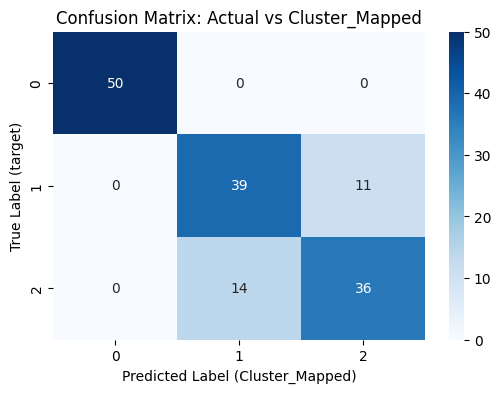

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(df['species'], df['Cluster_Mapped'])

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])

plt.xlabel('Predicted Label (Cluster_Mapped)')
plt.ylabel('True Label (target)')
plt.title('Confusion Matrix: Actual vs Cluster_Mapped')
plt.show()

In [53]:
# Now compare
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['species'], df['Cluster_Mapped'])
print("Accuracy after mapping:", accuracy)

Accuracy after mapping: 0.8333333333333334


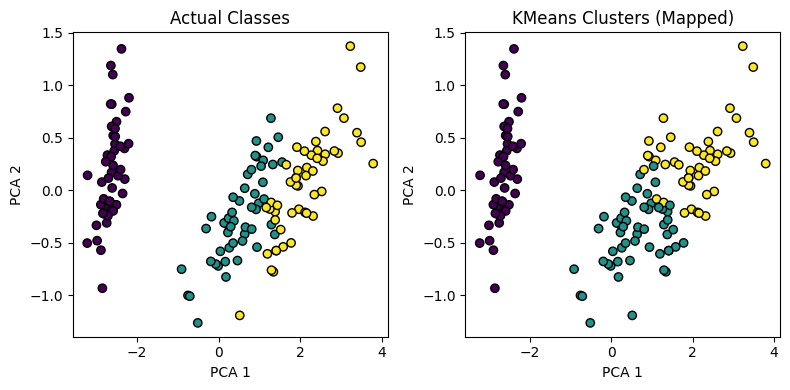

In [55]:
# Now lets reduce the dim to 2 using PCA. Then plot the actual classes and the Kmeans clusters with the labels
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(df.drop(['species', 'Cluster_With_Scaling', 'Cluster_Mapped'], axis=1))

plt.figure(figsize=(8,4))

# Actual classes
plt.subplot(1, 2, 1)
plt.scatter(reduced[:,0], reduced[:,1], c=df['species'], cmap='viridis', edgecolor='k')
plt.title("Actual Classes")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")

# Mapped Clusters
plt.subplot(1, 2, 2)
plt.scatter(reduced[:,0], reduced[:,1], c=df['Cluster_Mapped'], cmap='viridis', edgecolor='k')
plt.title("KMeans Clusters (Mapped)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()


## observation:
# The actual clusters almost match kmeans clusters. 

In [56]:
# Now lets measure the performance of our kmeans clustersing
# 1) silhouette_score:
# - Measures how well each point lies within its cluster
# - Considers cohesion (how close points in a cluster are) and separation (how far clusters are from each other)

# Range: -1 to 1
# 1 = well-clustered
# 0 = overlapping clusters
# <0 = bad clustering



from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_X, clusters_with_scaling)
print(f"Silhouette Score: {score:.3f}")


Silhouette Score: 0.459


In [57]:
# 2. Inertia (Within-Cluster Sum of Squares)
# - Comes directly from KMeans
# - Measures how tight the clusters are
# - Lower is better, but it always decreases with more clusters — so not a great standalone metric

print(f"Inertia (WCSS): {kmeans_with_scaling.inertia_}")


Inertia (WCSS): 140.96581663074699
